In [ ]:
import os
from concurrent.futures import ThreadPoolExecutor
from importlib import reload

import numpy as np
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt

from data_readers import data_loader as D
from data_readers.radar import RadarData

_= reload(D)

DATASET_PATH = os.path.abspath("../../../RF-Behavior")
FRAME_RATES = sorted([10, 12] + list(range(14,18)) + np.linspace(18,20, 21).tolist() + list(range(21,24)) + list(range(24,31,2)) )
print(f"FRAME_RATES: {FRAME_RATES}") # [10, 12, 14, 15, 16, 17, 18.0, 18.1, 18.2, 18.3, 18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19.0, 19.1, 19.2, 19.3, 19.4, 19.5, 19.6, 19.7, 19.8, 19.9, 20.0, 21, 22, 23, 24, 26, 28, 30]

FRAME_RATES: [10, 12, 14, 15, 16, 17, 18.0, 18.1, 18.2, 18.3, 18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19.0, 19.1, 19.2, 19.3, 19.4, 19.5, 19.6, 19.7, 19.8, 19.9, 20.0, 21, 22, 23, 24, 26, 28, 30]


In [13]:
def n_frames_vs_n_pts(path, frame_rates=tuple(FRAME_RATES)):
    n_frames, n_pts = [], []
    r = RadarData.read_from_path(path)
    for fps in frame_rates:
        binned = r.bin(fps=fps)
        n_frames.append(binned.n_frames)
        n_pts.append(float(np.mean([len(f) for f in binned.points])))
    return n_frames, n_pts

def normalized_squared_error(ps, fs):
    ps = np.array(ps)
    fs = np.array(fs)
    ps = (ps - np.mean(ps)) / np.std(ps)
    fs = (fs - np.mean(fs)) / np.std(fs)
    return (fs - ps)**2

In [ ]:
df = D.find_available_files(DATASET_PATH).dropna(subset=["radar_path"]).reset_index(drop=True)

with ThreadPoolExecutor(max_workers=8) as executor:
    stats = list(tqdm(executor.map(n_frames_vs_n_pts, df["radar_path"]), total=len(df)))

n_frames, n_pts = zip(*stats)
df["n_frames"] = n_frames
df["n_pts"] = n_pts

df["nse"] = df.apply(lambda row: normalized_squared_error(row["n_frames"], row["n_pts"]), axis=1)
df["best_fps"] = df["nse"].apply(lambda x: FRAME_RATES[np.argmin(x)])
COLS = ["campaign", "behavior", "user", "repetition", "best_fps", "n_frames", "n_pts", "nse"]
df = df[COLS].sort_values(by=COLS[:4])
df.to_csv("radar_fps_vs_n_frames_vs_n_pts.csv", index=False)
df[COLS[:-1]]

,campaign,behavior,user,repetition,best_fps,n_frames,n_pts
0,C1,M01,U01,1,18.9,"[22, 26, 30, 32, 35, 37, 39, 39, 39, 39, 40, 4...","[57.59090909090909, 48.73076923076923, 42.2333..."
1,C1,M01,U01,2,18.9,"[19, 22, 26, 28, 29, 31, 33, 33, 33, 34, 34, 3...","[63.73684210526316, 55.04545454545455, 46.5769..."
2,C1,M01,U01,3,18.8,"[20, 24, 27, 29, 31, 33, 35, 35, 36, 36, 35, 3...","[45.0, 37.5, 33.333333333333336, 31.0344827586..."
3,C1,M01,U01,4,18.7,"[17, 20, 24, 25, 27, 29, 30, 31, 31, 31, 31, 3...","[49.470588235294116, 42.05, 35.041666666666664..."
4,C1,M01,U01,5,18.9,"[22, 27, 31, 33, 35, 37, 40, 40, 40, 40, 40, 4...","[53.22727272727273, 43.370370370370374, 37.774..."
...,...,...,...,...,...,...,...
6259,C3,E06,U33,1,18.2,"[2207, 2565, 2868, 2991, 3142, 3252, 3348, 334...","[6.184413230629814, 5.321247563352826, 4.75906..."
6265,C3,E06,U35,1,18.7,"[3490, 4077, 4631, 4859, 5169, 5383, 5626, 564...","[12.620916905444126, 10.803777287220996, 9.511..."
6271,C3,E06,U38,1,18.8,"[430, 498, 564, 597, 630, 658, 684, 681, 689, ...","[10.025581395348837, 8.656626506024097, 7.6436..."
6277,C3,E06,U41,1,18.7,"[404, 487, 554, 574, 608, 636, 666, 663, 668, ...","[9.727722772277227, 8.069815195071868, 7.09386..."


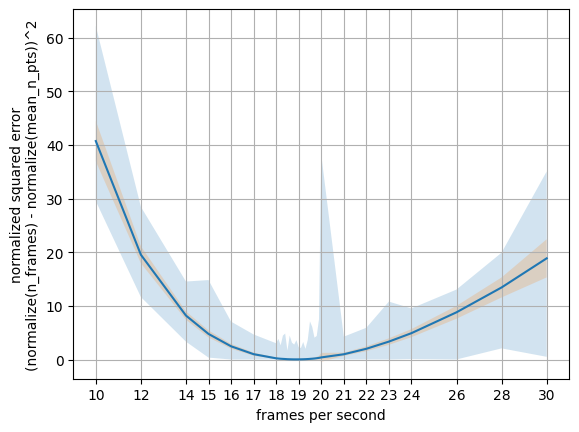

In [28]:
nse  = np.stack(df["nse"])
y    = np.mean (nse, axis=0)
err  = np.std  (nse, axis=0)
mins = np.min  (nse, axis=0)
maxs = np.max  (nse, axis=0)
plt.fill_between(FRAME_RATES,  mins,  maxs, alpha=0.2)
plt.fill_between(FRAME_RATES, y-err, y+err, alpha=0.2)
plt.plot(FRAME_RATES, y)
plt.xticks(sorted({int(x) for x in FRAME_RATES}))
plt.grid(True)
plt.xlabel("frames per second")
plt.ylabel("normalized squared error\n(normalize(n_frames) - normalize(mean_n_pts))^2")
plt.show()

In [20]:
df.best_fps.mean()

np.float64(18.681524506683644)

In [27]:
df.groupby(["campaign", "behavior"])["best_fps"].mean()#.plot.barh(figsize=(8,6), title="Mean best fps per behavior")

campaign  behavior
C1        M01         18.789500
          M02         18.839234
          M03         18.813876
          M04         18.757895
          M05         18.723445
          M06         18.760766
          M07         18.772727
          M08         18.769948
          M09         18.756995
          M10         18.879208
          M11         18.724752
          M12         18.699505
          M13         18.706931
          M14         18.741584
          M15         18.820430
          M16         18.831720
          M17         18.827723
          M18         18.817327
          M19         18.706452
          M20         18.837097
          M21         18.819892
C2        A01         18.702500
          A02         18.713000
          A03         18.498500
          A04         18.367500
          A05         18.528804
          A06         18.513043
          A07         18.328500
          A08         18.371500
          A09         18.278500
          A10        